✅ Tải dữ liệu Excel thành công! Bắt đầu vẽ biểu đồ...


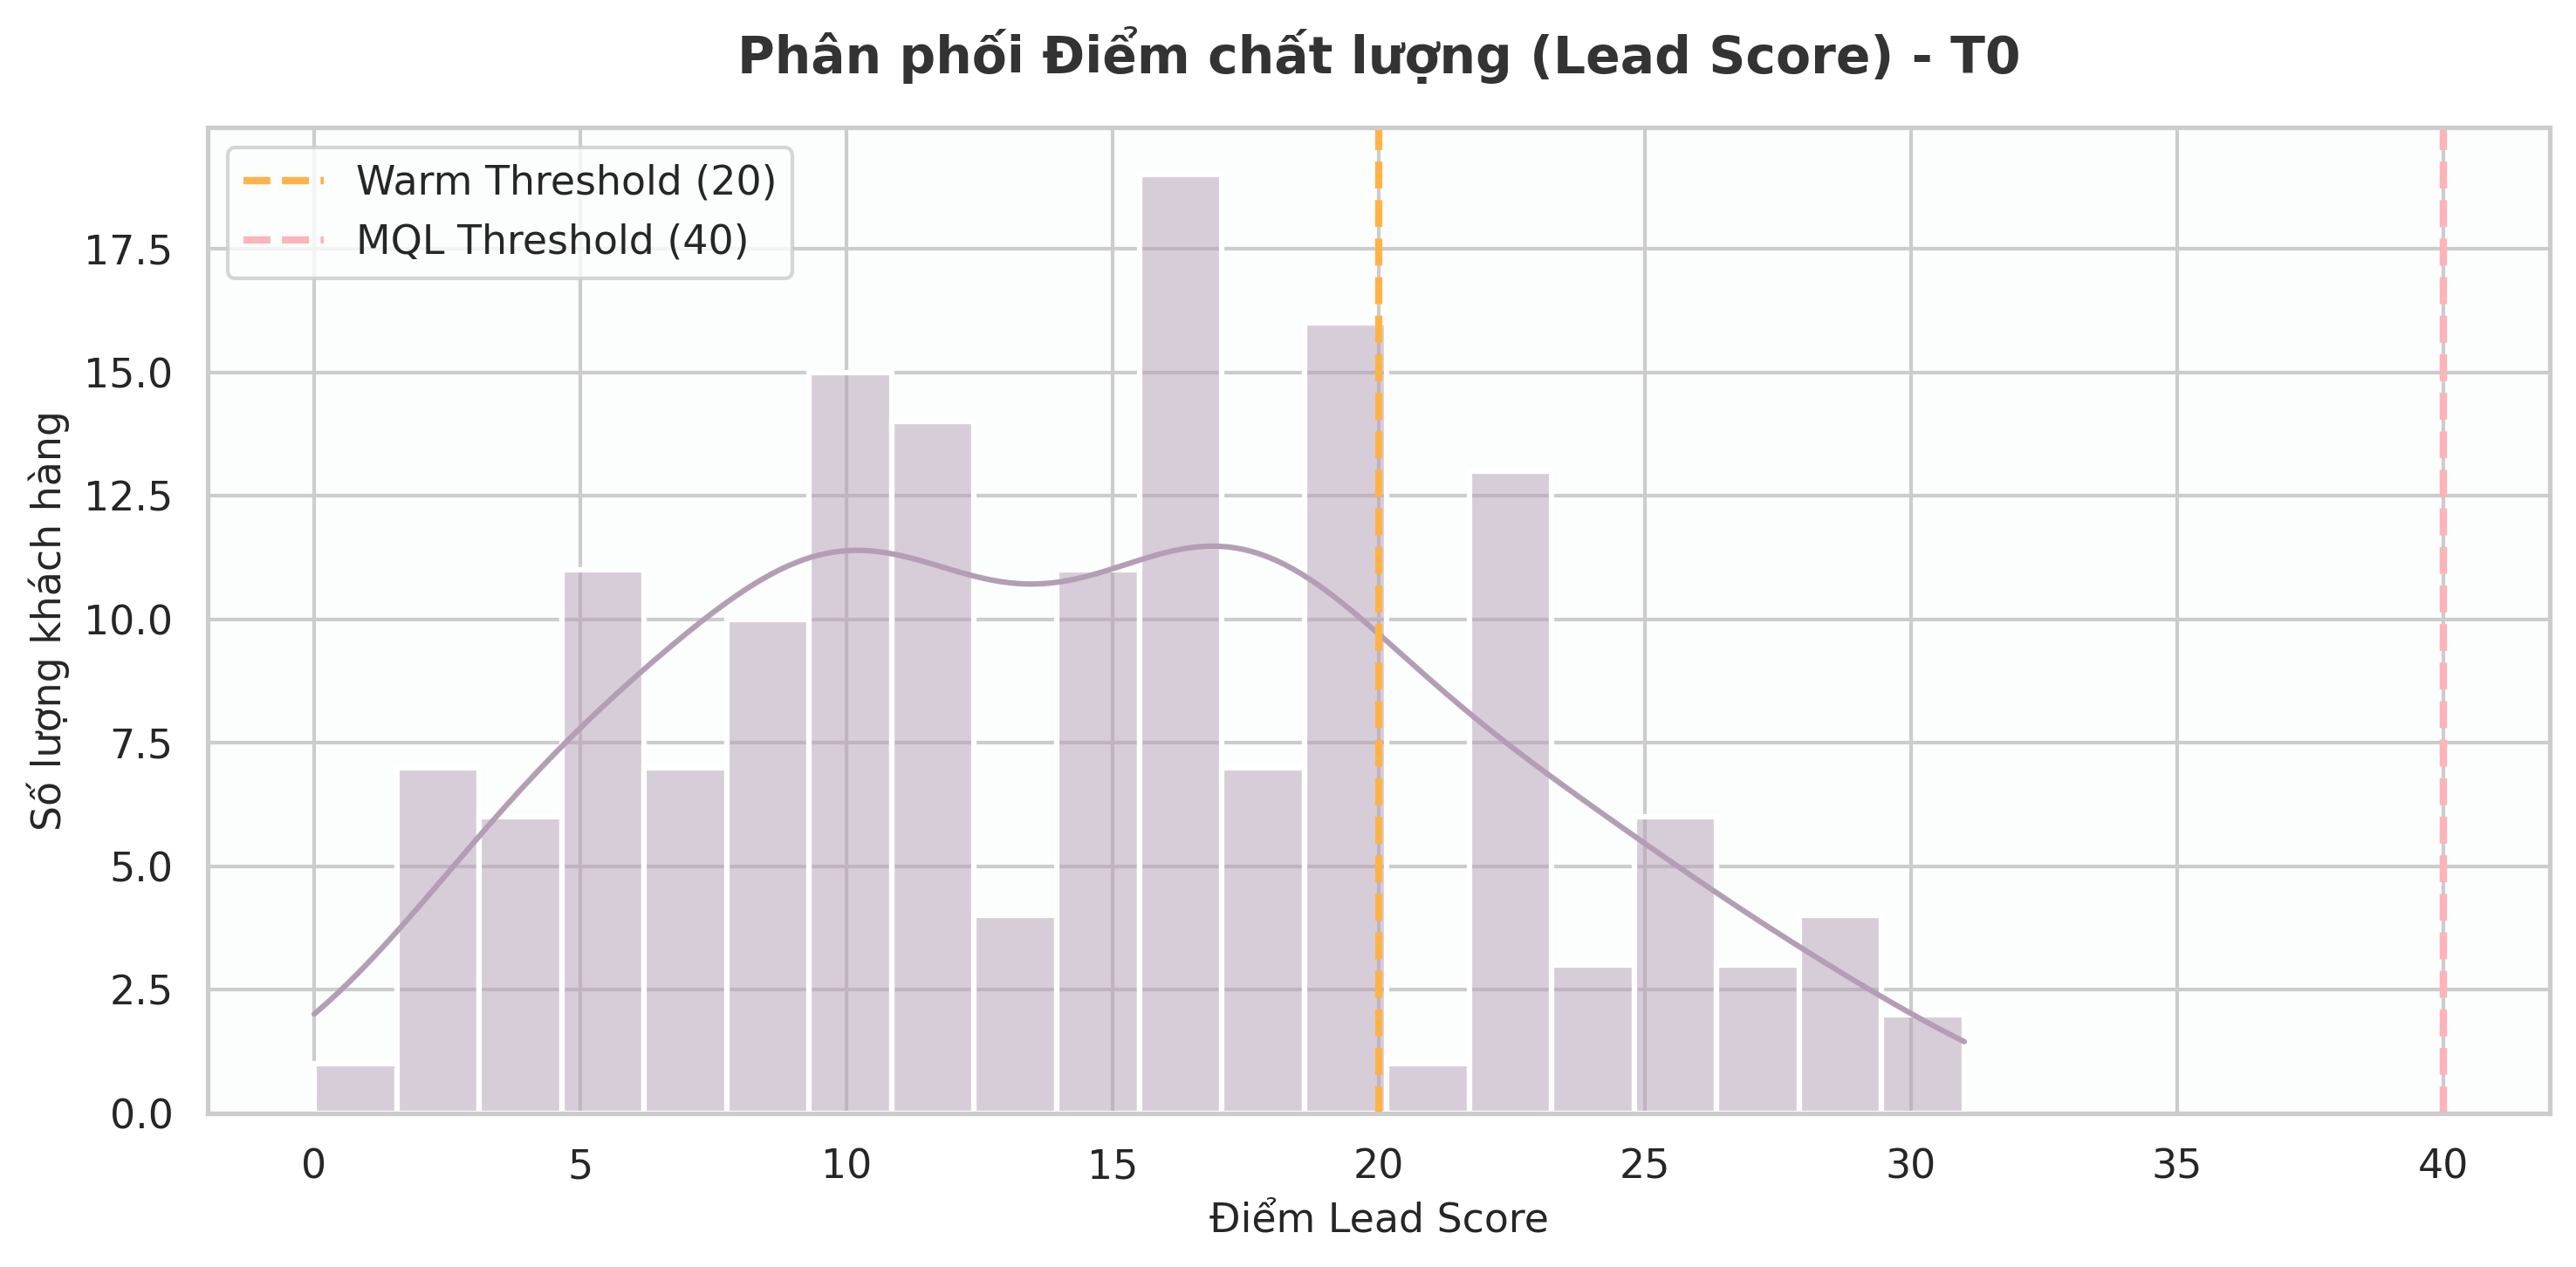

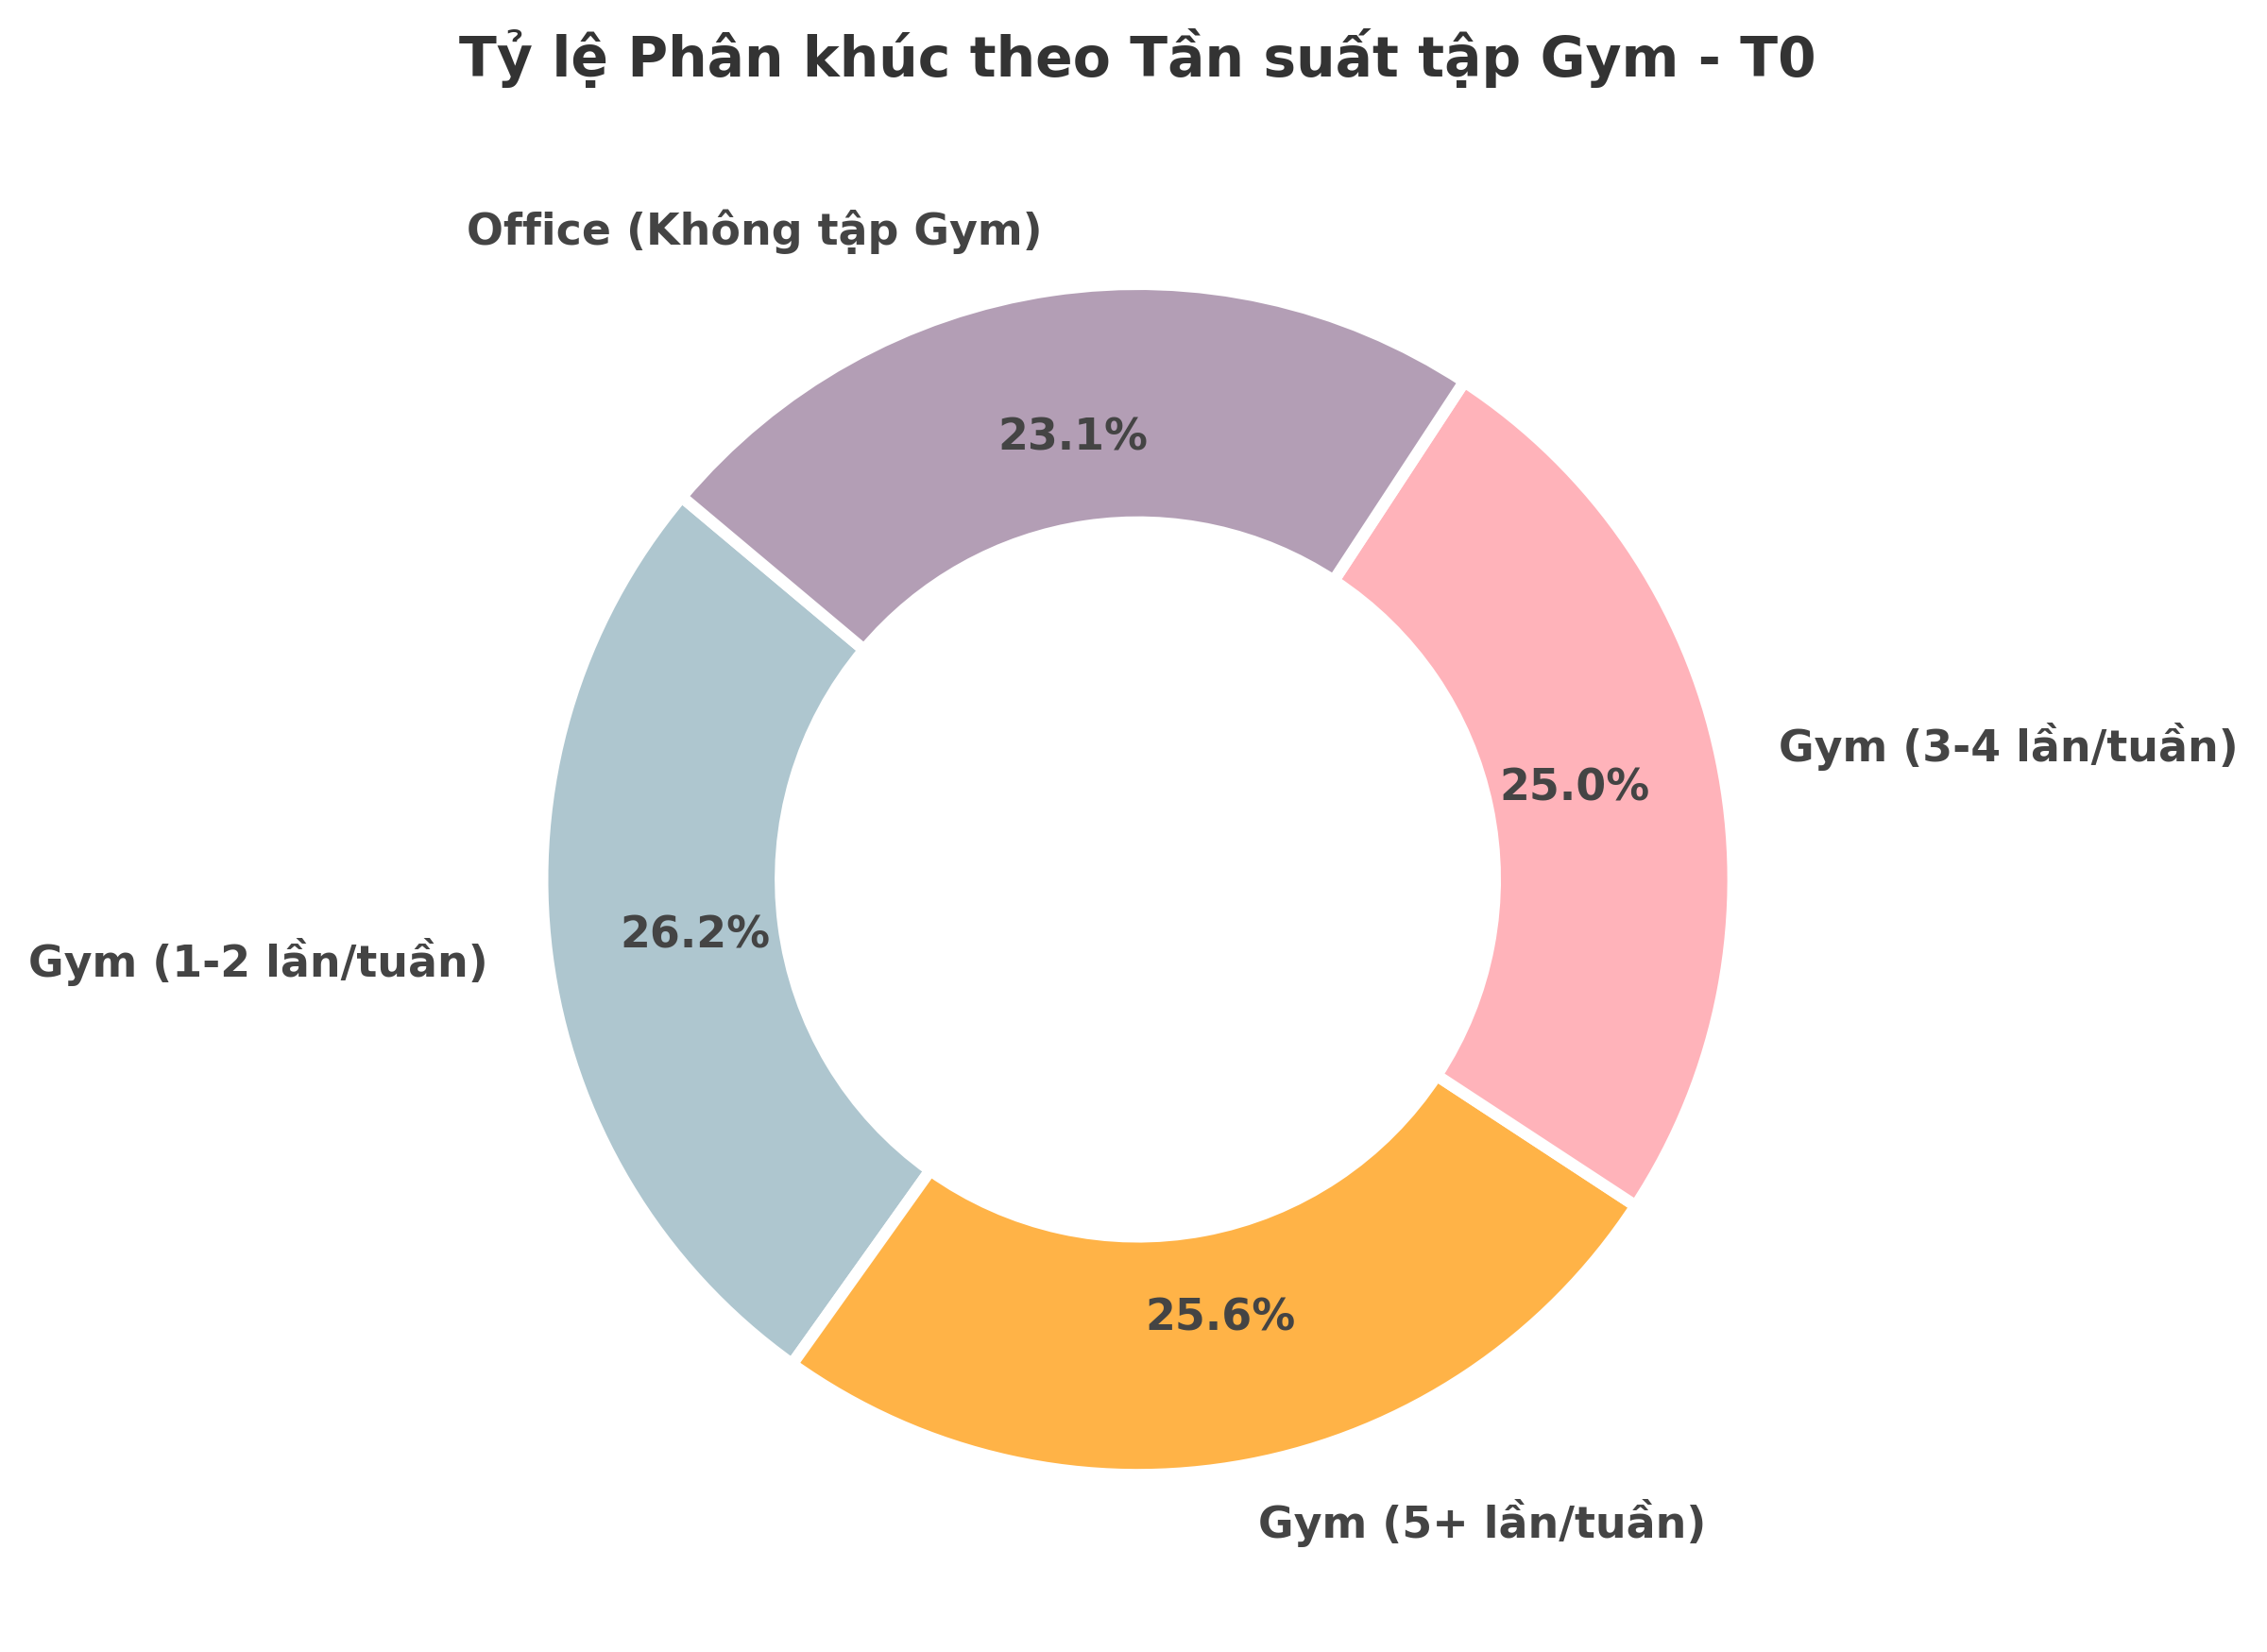

/tmp/ipykernel_2599/2240569849.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.barplot(data=source_counts, y='Source', x='Count', palette="pastel")


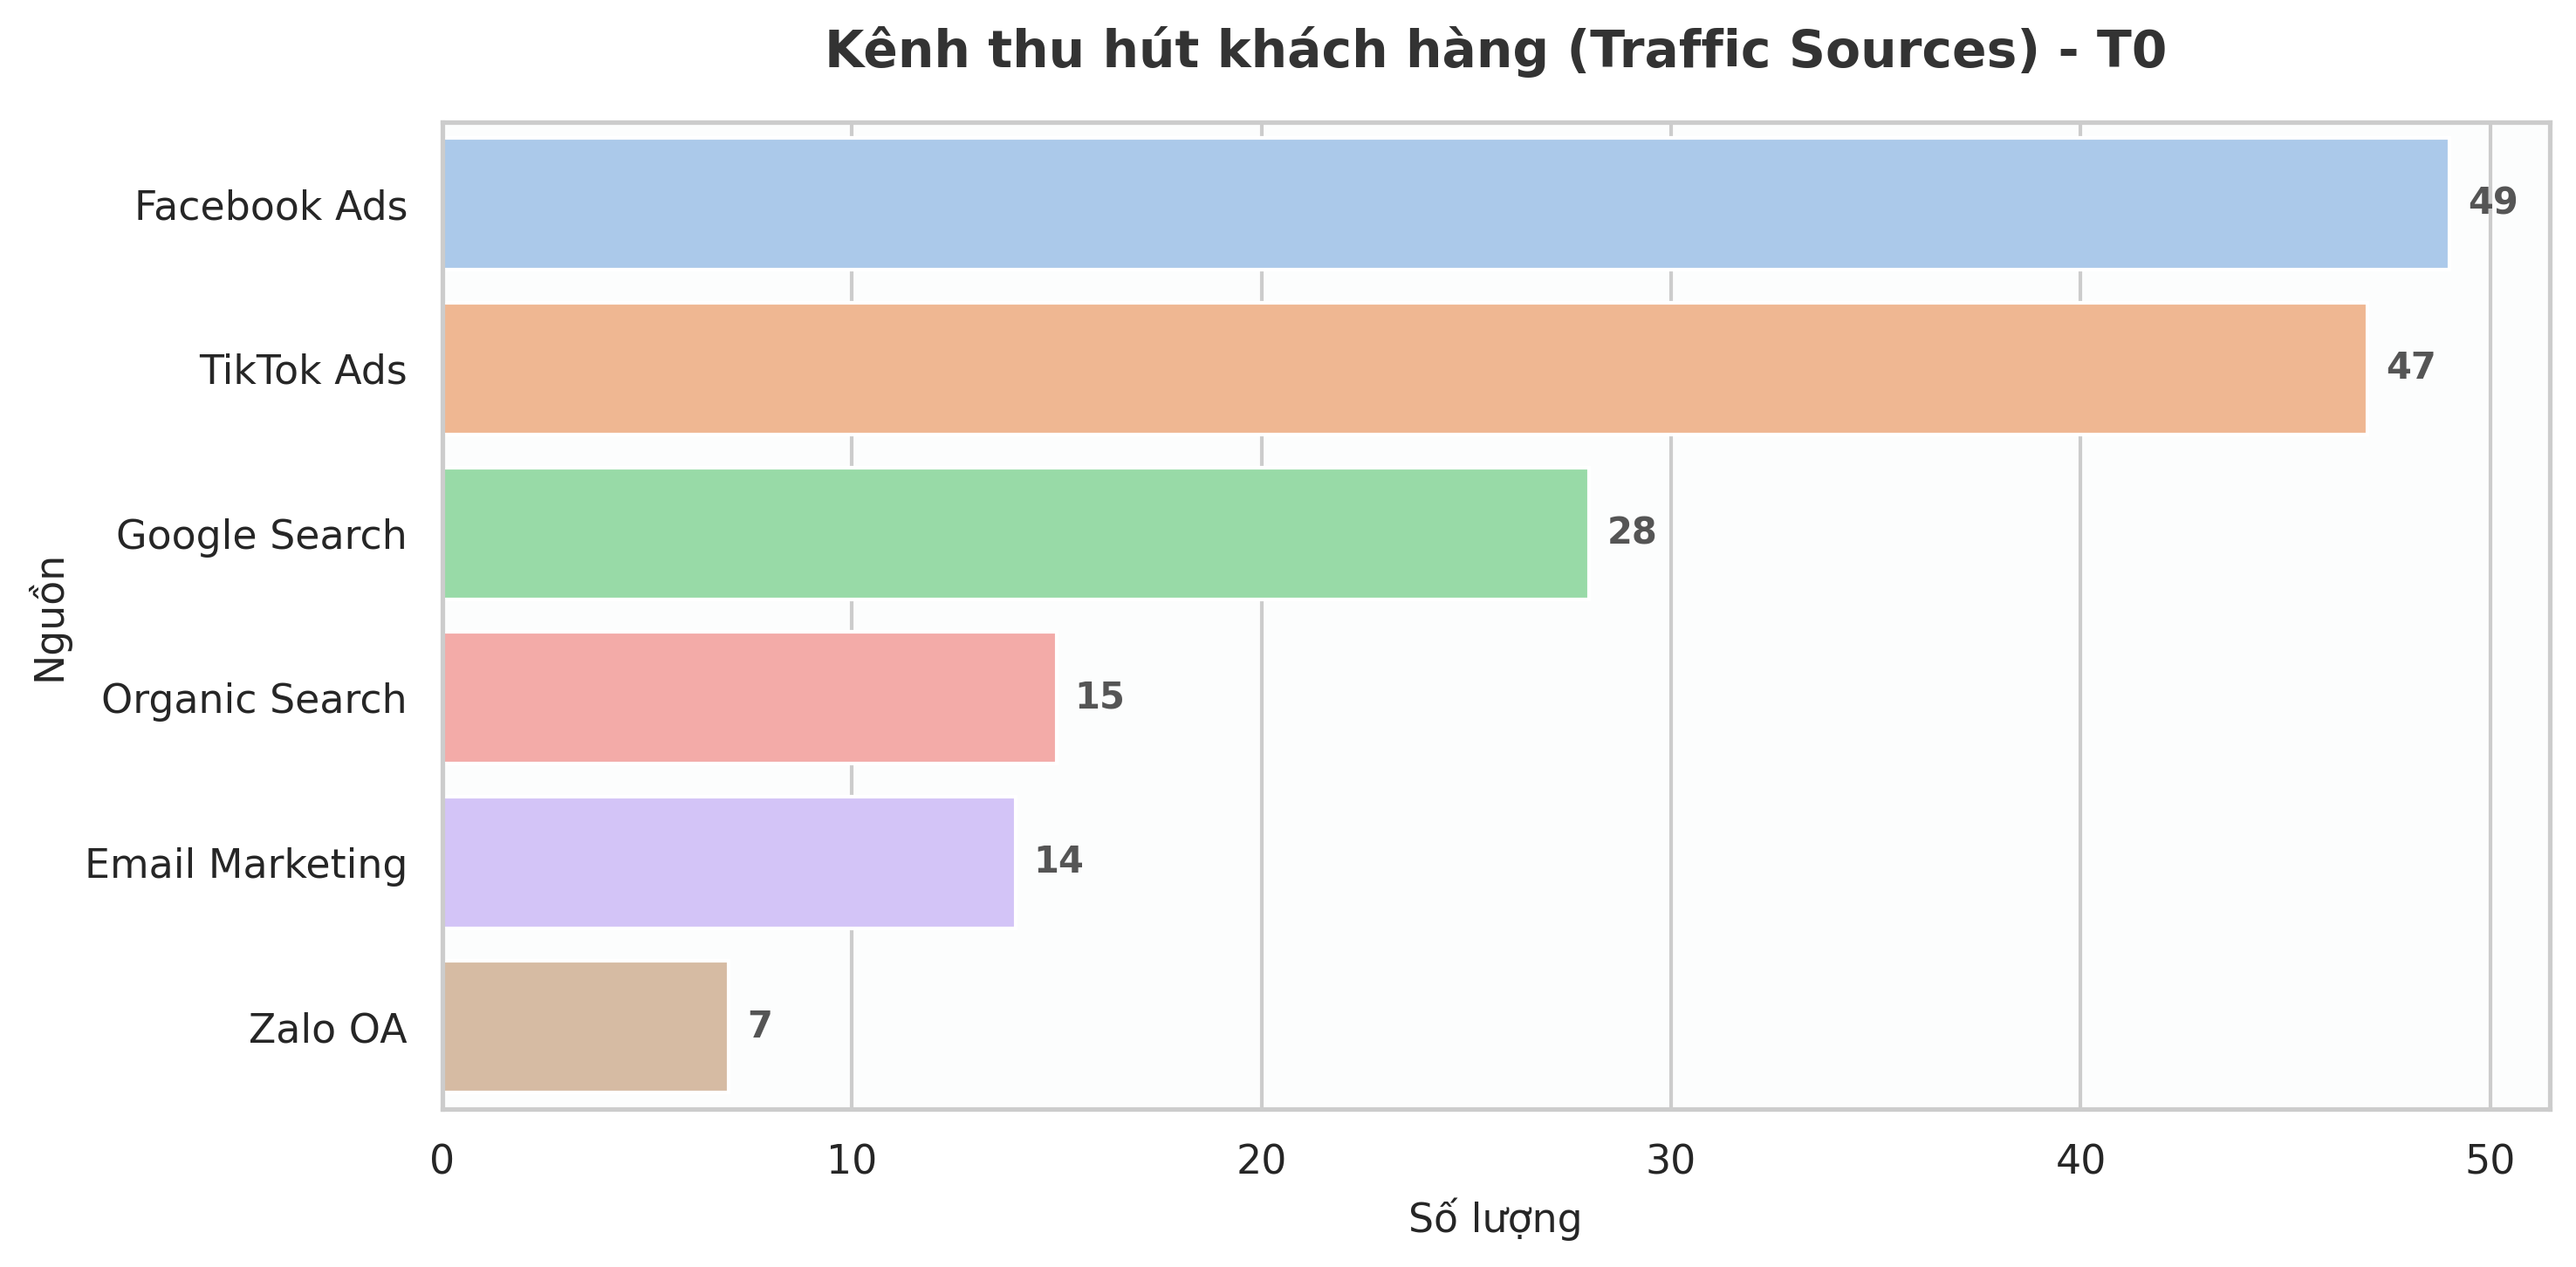

/tmp/ipykernel_2599/2240569849.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x=stage_counts.index, y=stage_counts.values, palette=["#AEC6CF", "#FFB347", "#FFB3BA"])


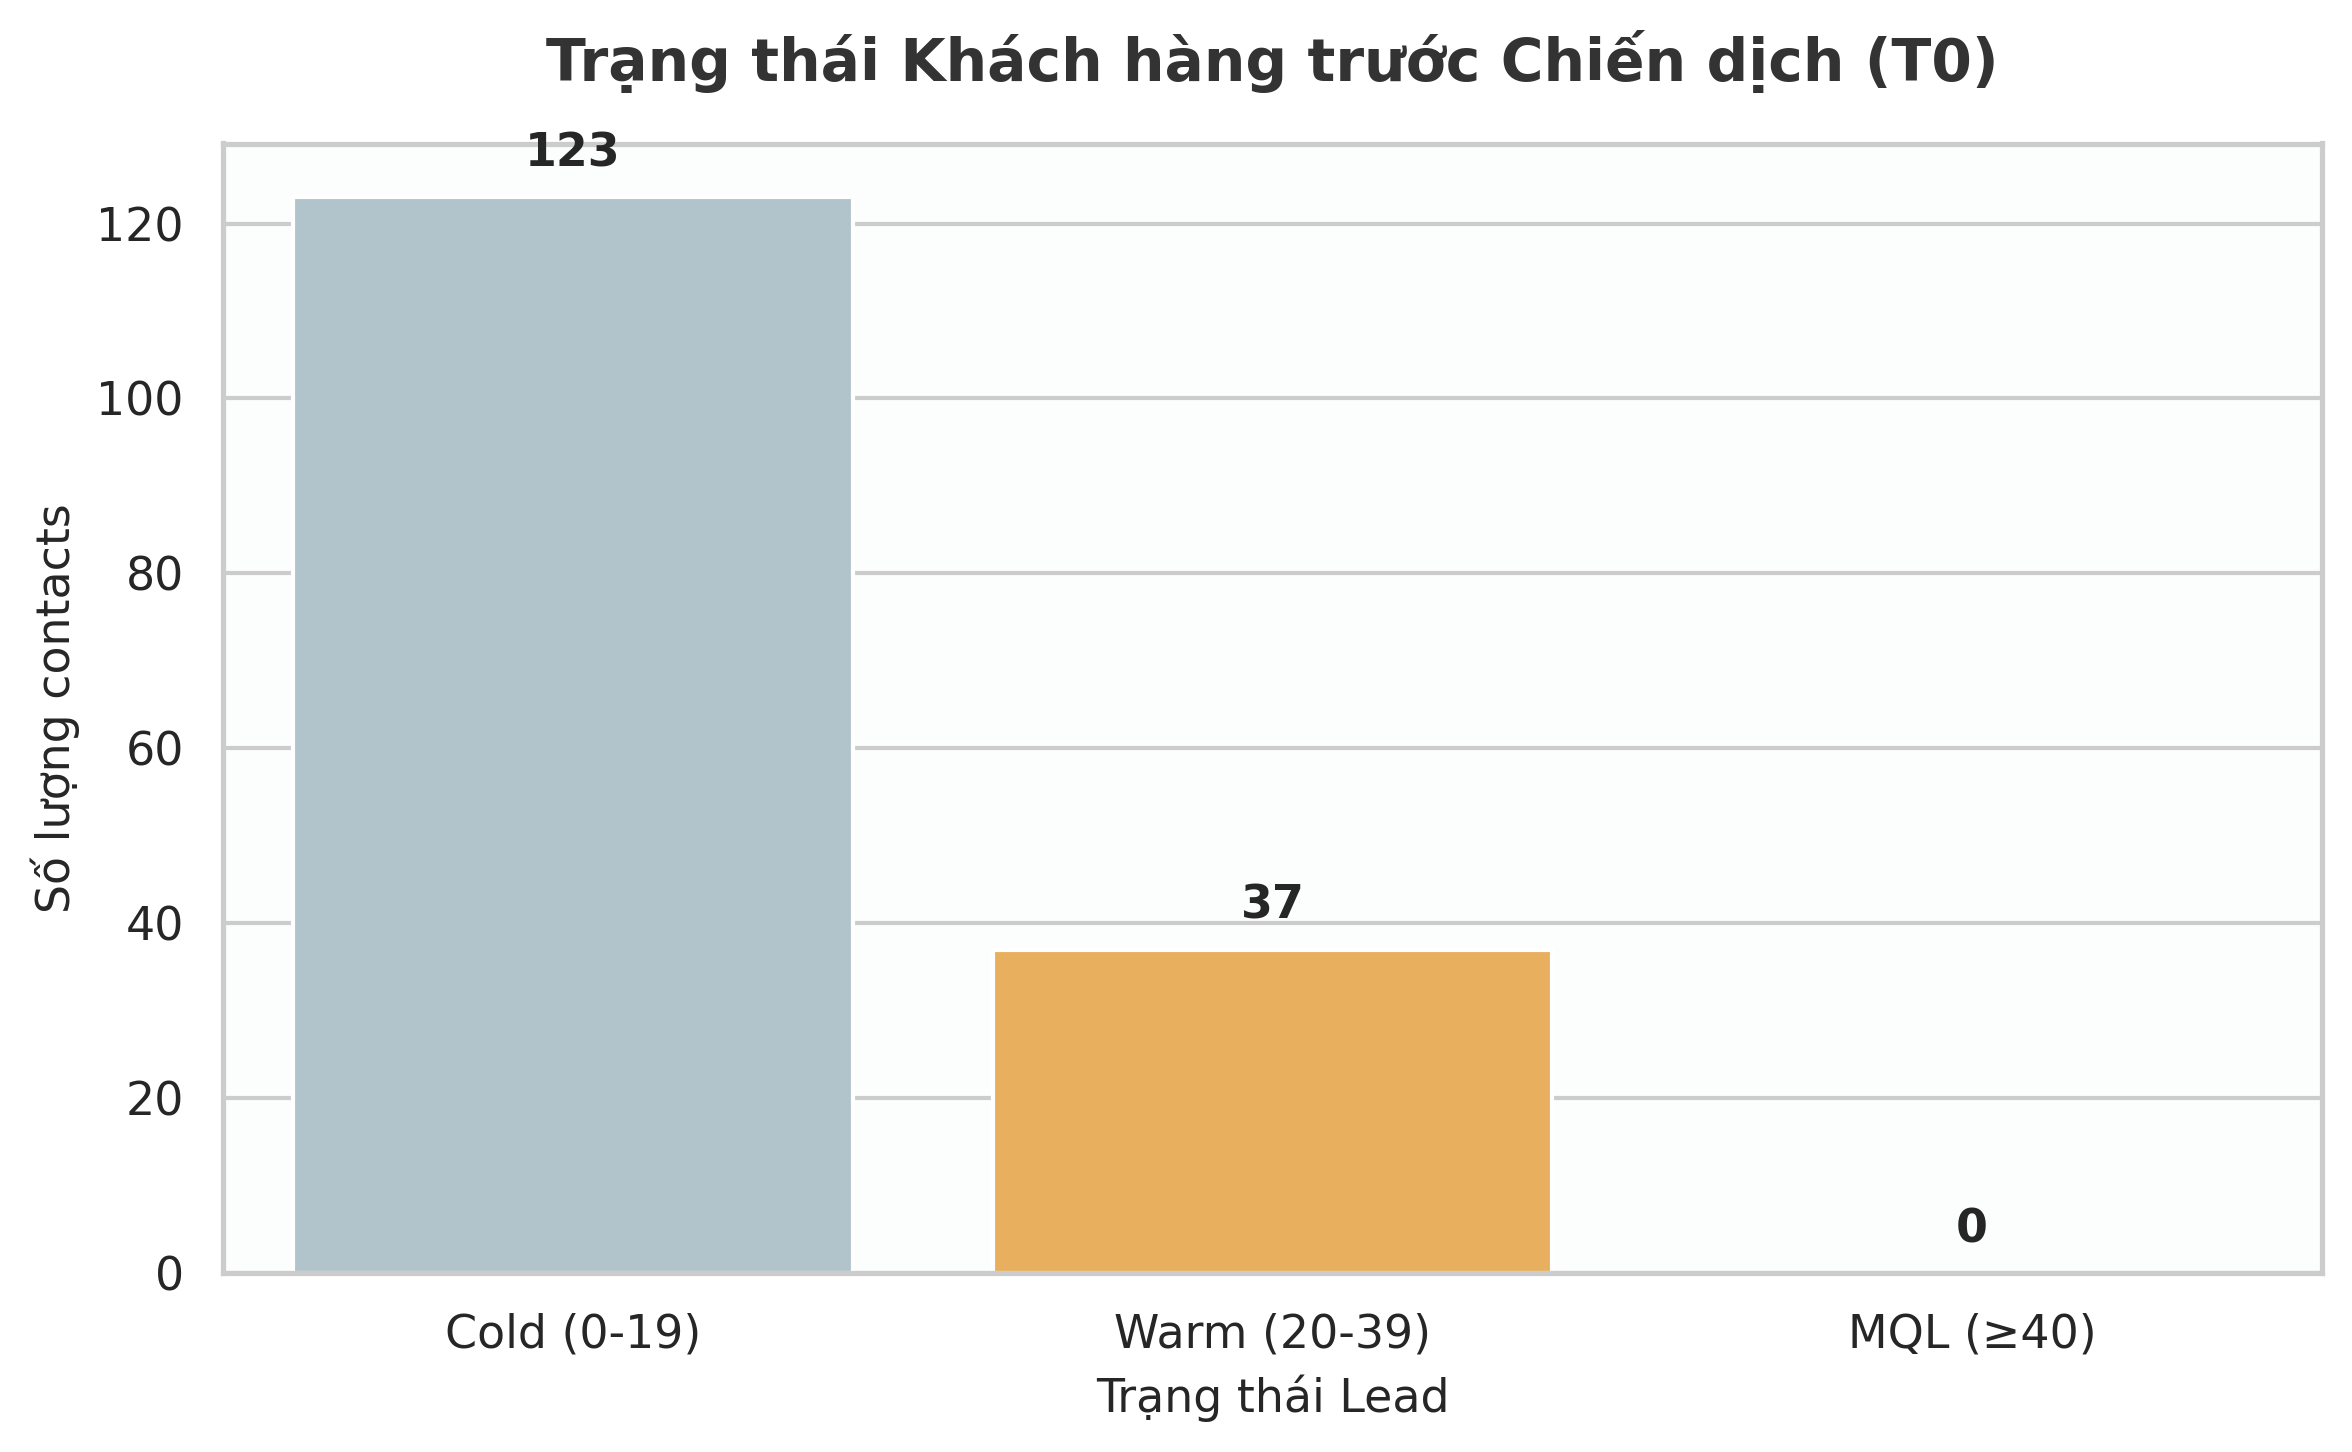

🎉 Xong luôn! Đã chia đủ 4 mức độ Gym, bạn tải ảnh về xem thử ưng bụng chưa nha!


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. CẤU HÌNH GIAO DIỆN PASTEL & ĐỘ NÉT CAO (300 DPI)
# ==========================================
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#FCFDFD", "figure.facecolor": "#FFFFFF"})

# Bảng màu Pastel chuẩn Gu Thời trang Coolmate
pastel_colors = ["#AEC6CF", "#FFB347", "#FFB3BA", "#B39EB5", "#FFDFBA", "#CFCFC4"]
sns.set_palette(sns.color_palette(pastel_colors))

plt.rcParams.update({'figure.dpi': 300, 'savefig.dpi': 300})
plt.rcParams['font.sans-serif'] = ['Arial']

# ==========================================
# 2. ĐỌC VÀ XỬ LÝ DỮ LIỆU TỪ FILE EXCEL (.XLSX)
# ==========================================
try:
    df = pd.read_excel('coolmate_contacts_T0_before.xlsx')
except FileNotFoundError:
    print("❌ LỖI: Chưa tải file Excel lên Colab. Vui lòng tải file lên thư mục ảo của Colab trước!")
    raise

# Xử lý cột Lead Score
df['lead_score_t0'] = pd.to_numeric(df['lead_score_t0'], errors='coerce').fillna(0)

# Phân loại trạng thái Lead
def categorize_lead(score):
    if score >= 40: return 'MQL (≥40)'
    elif score >= 20: return 'Warm (20-39)'
    else: return 'Cold (0-19)'
df['Lead_Stage'] = df['lead_score_t0'].apply(categorize_lead)

# 🔥 ĐÃ SỬA: Phân khúc chi tiết theo tần suất Gym của bạn
def create_segment(row):
    gym = str(row.get('gym_frequency', '')).lower()
    if '1' in gym or '2' in gym:
        return 'Gym (1-2 lần/tuần)'
    elif '3' in gym or '4' in gym:
        return 'Gym (3-4 lần/tuần)'
    elif '5' in gym or '+' in gym:
        return 'Gym (5+ lần/tuần)'
    else:
        return 'Office (Không tập Gym)'
df['Segment'] = df.apply(create_segment, axis=1)

print("✅ Tải dữ liệu Excel thành công! Bắt đầu vẽ biểu đồ...")

# ==========================================
# 3. VẼ CÁC BIỂU ĐỒ MINH HỌA (LƯU THÀNH ẢNH)
# ==========================================

# 🎨 Hình 1: Phân phối điểm Lead Score (KDE Histogram)
plt.figure(figsize=(10, 5))
ax1 = sns.histplot(data=df, x='lead_score_t0', bins=20, kde=True, color="#B39EB5", edgecolor='white', linewidth=1.5)
plt.axvline(x=20, color='#FFB347', linestyle='--', linewidth=2, label='Warm Threshold (20)')
plt.axvline(x=40, color='#FFB3BA', linestyle='--', linewidth=2, label='MQL Threshold (40)')
plt.title('Phân phối Điểm chất lượng (Lead Score) - T0', fontsize=14, fontweight='bold', color='#333333', pad=15)
plt.xlabel('Điểm Lead Score', fontsize=11)
plt.ylabel('Số lượng khách hàng', fontsize=11)
plt.legend()
plt.tight_layout()
plt.savefig('Chart_1_LeadScore_Dist.png')
plt.show()

# 🔥 ĐÃ SỬA: Hình 2: Phân khúc Khách hàng (Chia 4 miếng bánh)
plt.figure(figsize=(8, 8))
segment_counts = df['Segment'].value_counts()
# Dùng 4 màu pastel cho 4 phân khúc
pie_colors = ["#AEC6CF", "#FFB347", "#FFB3BA", "#B39EB5"]
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%',
        colors=pie_colors, startangle=140,
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3),
        textprops={'fontsize': 11, 'fontweight': 'bold', 'color': '#444444'},
        pctdistance=0.75)
plt.title('Tỷ lệ Phân khúc theo Tần suất tập Gym - T0', fontsize=14, fontweight='bold', color='#333333', pad=15)
plt.tight_layout()
plt.savefig('Chart_2_Segments_Donut.png')
plt.show()

# 🎨 Hình 3: Nguồn Traffic (Horizontal Bar Chart)
plt.figure(figsize=(10, 5))
source_counts = df['source'].value_counts().reset_index()
source_counts.columns = ['Source', 'Count']
ax3 = sns.barplot(data=source_counts, y='Source', x='Count', palette="pastel")
for p in ax3.patches:
    ax3.annotate(f"{int(p.get_width())}",
                 (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', xytext=(5, 0), textcoords='offset points',
                 fontsize=10, color='#555555', fontweight='bold')
plt.title('Kênh thu hút khách hàng (Traffic Sources) - T0', fontsize=14, fontweight='bold', color='#333333', pad=15)
plt.xlabel('Số lượng', fontsize=11)
plt.ylabel('Nguồn', fontsize=11)
plt.tight_layout()
plt.savefig('Chart_3_Traffic_Sources.png')
plt.show()

# 🎨 Hình 4: Trạng thái Phễu - Đánh giá độ lạnh/nóng của Data
plt.figure(figsize=(8, 5))
stage_counts = df['Lead_Stage'].value_counts().reindex(['Cold (0-19)', 'Warm (20-39)', 'MQL (≥40)']).fillna(0)
ax4 = sns.barplot(x=stage_counts.index, y=stage_counts.values, palette=["#AEC6CF", "#FFB347", "#FFB3BA"])
for p in ax4.patches:
    ax4.annotate(f"{int(p.get_height())}",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                 fontsize=11, fontweight='bold')
plt.title('Trạng thái Khách hàng trước Chiến dịch (T0)', fontsize=14, fontweight='bold', color='#333333', pad=15)
plt.ylabel('Số lượng contacts', fontsize=11)
plt.xlabel('Trạng thái Lead', fontsize=11)
plt.tight_layout()
plt.savefig('Chart_4_Lead_Stages.png')
plt.show()

print("🎉 Xong luôn! Đã chia đủ 4 mức độ Gym, bạn tải ảnh về xem thử ưng bụng chưa nha!")